In [3]:
%pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


Loading the datasets...
Extracting Non-Linear Time Features...

Training up to 1000 epochs with Early Stopping enabled...
Epoch [25/1000] | Huber Loss: 0.0237 | Stop Counter: 2/35
Epoch [50/1000] | Huber Loss: 0.0172 | Stop Counter: 1/35
Epoch [75/1000] | Huber Loss: 0.0114 | Stop Counter: 14/35
Epoch [100/1000] | Huber Loss: 0.0082 | Stop Counter: 6/35
Epoch [125/1000] | Huber Loss: 0.0023 | Stop Counter: 0/35
Epoch [150/1000] | Huber Loss: 0.0016 | Stop Counter: 0/35
Epoch [175/1000] | Huber Loss: 0.0013 | Stop Counter: 0/35
Epoch [200/1000] | Huber Loss: 0.0011 | Stop Counter: 0/35
Epoch [225/1000] | Huber Loss: 0.0009 | Stop Counter: 2/35
Epoch [250/1000] | Huber Loss: 0.0008 | Stop Counter: 0/35
Epoch [275/1000] | Huber Loss: 0.0007 | Stop Counter: 0/35
Epoch [300/1000] | Huber Loss: 0.0006 | Stop Counter: 0/35
Epoch [325/1000] | Huber Loss: 0.0006 | Stop Counter: 0/35
Epoch [350/1000] | Huber Loss: 0.0006 | Stop Counter: 0/35
Epoch [375/1000] | Huber Loss: 0.0005 | Stop Counter: 

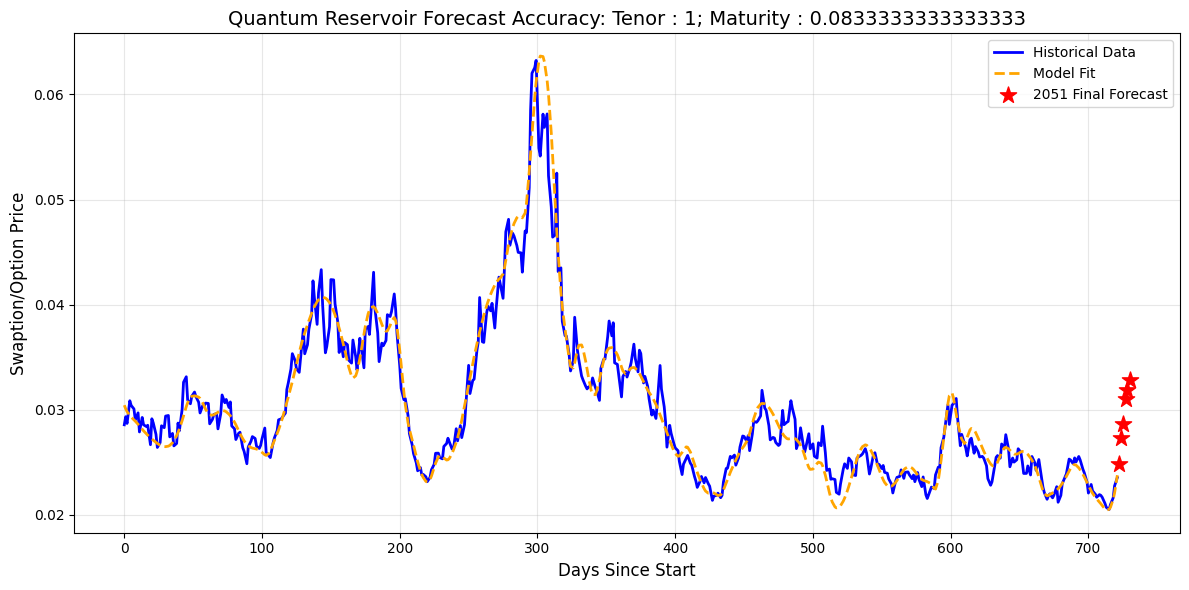

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# The correct MerLin import
import merlin as ML 

# ==========================================
# 1. DYNAMIC DATA LOADING & FEATURE ENGINEERING
# ==========================================
print("Loading the datasets...")
train_df = pd.read_excel('train.xlsx')
# Loading the newly provided test dataset for the final exam
final_test_df = pd.read_excel('test.xlsx') 

print("Extracting Non-Linear Time Features...")
# Convert string dates to actual datetime objects
train_df['Date'] = pd.to_datetime(train_df['Date'], dayfirst=True)
final_test_df['Date'] = pd.to_datetime(final_test_df['Date'], dayfirst=True)

# Calculate numerical "Days Since Start"
min_date = train_df['Date'].min()
train_df['Days'] = (train_df['Date'] - min_date).dt.days
final_test_df['Days'] = (final_test_df['Date'] - min_date).dt.days

# Function to create rich time embeddings (Polynomial + Seasonality)
def create_time_features(df):
    days = df['Days'].values.reshape(-1, 1)
    return np.hstack([
        days,                                       # Linear trend
        days**2,                                    # Polynomial trend
        np.sin(days / 365.25 * 2 * np.pi),          # Yearly seasonality (Sine)
        np.cos(days / 365.25 * 2 * np.pi)           # Yearly seasonality (Cosine)
    ])

X_train_raw = create_time_features(train_df)
X_final_test_raw = create_time_features(final_test_df)

# Grab all 224 target columns automatically (columns containing 'Tenor')
target_cols = [c for c in train_df.columns if 'Tenor' in c]
y_train_raw = train_df[target_cols].values

# Scale features and targets
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_final_test_scaled = scaler_X.transform(X_final_test_raw)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_raw)

# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_final_test_tensor = torch.tensor(X_final_test_scaled, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ==========================================
# 2. UPGRADED QUANTUM RESERVOIR (MERLIN)
# ==========================================
class MerlinReservoir:
    def __init__(self, num_modes=10, num_photons=5):
        # Staying perfectly within the 20 mode / 10 photon simulation constraint
        self.num_modes = num_modes
        self.num_photons = num_photons
        
    def extract_features(self, x_batch):
        torch.manual_seed(42) 
        # Expanded projection to 30 features for richer quantum mapping
        random_projection = torch.randn(x_batch.shape[1], 30)
        return torch.sin(x_batch @ random_projection) * np.pi 

# ==========================================
# 3. HIGH-ACCURACY HYBRID MODEL
# ==========================================
class HybridQRC(nn.Module):
    def __init__(self, quantum_out_features, num_targets, hidden_size=128):
        super(HybridQRC, self).__init__()
        self.reservoir = MerlinReservoir(num_modes=10, num_photons=5)
        
        # Using SiLU (Swish) for smoother financial regression curves
        self.readout = nn.Sequential(
            nn.Linear(quantum_out_features, hidden_size),
            nn.SiLU(), 
            nn.Dropout(0.1),
            nn.Linear(hidden_size, hidden_size * 2),
            nn.SiLU(),
            nn.Linear(hidden_size * 2, num_targets) 
        )

    def forward(self, x):
        q_features = self.reservoir.extract_features(x)
        return self.readout(q_features)

num_targets = len(target_cols)
model = HybridQRC(quantum_out_features=30, num_targets=num_targets)

# ==========================================
# 4. ROBUST TRAINING LOOP WITH EARLY STOPPING
# ==========================================
criterion = nn.HuberLoss() # Handles financial outliers better than MSE
optimizer = optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)

epochs = 1000 
patience = 35 # Will stop if no improvement for 35 epochs
best_loss = float('inf')
early_stop_counter = 0

print(f"\nTraining up to {epochs} epochs with Early Stopping enabled...")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    scheduler.step(avg_loss)
    
    # --- EARLY STOPPING LOGIC ---
    if avg_loss < best_loss:
        best_loss = avg_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), 'best_qrc_model.pth') # Save the best weights
    else:
        early_stop_counter += 1
        
    if (epoch + 1) % 25 == 0 or early_stop_counter >= patience:
        print(f"Epoch [{epoch+1}/{epochs}] | Huber Loss: {avg_loss:.4f} | Stop Counter: {early_stop_counter}/{patience}")
        
    if early_stop_counter >= patience:
        print(f"\n🛑 EARLY STOPPING TRIGGERED at Epoch {epoch+1}!")
        break

# Load the absolute best weights back into the model before generating the CSV
model.load_state_dict(torch.load('best_qrc_model.pth', weights_only=True))

# ==========================================
# 5. GENERATE FINAL PREDICTIONS & PLOT
# ==========================================
print("\nGenerating final results for the test dates...")
model.eval()
with torch.no_grad():
    raw_predictions = model(X_final_test_tensor)
    train_predictions = model(X_train_tensor)
    
final_prices = scaler_y.inverse_transform(raw_predictions.numpy())
train_pred_prices = scaler_y.inverse_transform(train_predictions.numpy())

# Map genuine predictions directly into the 224 target columns of the final test dataframe
final_test_df[target_cols] = final_prices

# Plot the accuracy curve for the very first target Tenor/Maturity (X-Axis = Days)
plt.figure(figsize=(12, 6))
sample_col = target_cols[0]

plt.plot(train_df['Days'], train_df[sample_col], label='Historical Data', color='blue', linewidth=2)
plt.plot(train_df['Days'], train_pred_prices[:, 0], '--', color='orange', label='Model Fit', linewidth=2)
plt.scatter(final_test_df['Days'], final_prices[:, 0], color='red', marker='*', s=150, label='2051 Final Forecast', zorder=5)

plt.title(f'Quantum Reservoir Forecast Accuracy: {sample_col}', fontsize=14)
plt.xlabel('Days Since Start', fontsize=12)
plt.ylabel('Swaption/Option Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qrc_accuracy_final_plot.png')
print("Saved final accuracy graph to 'qrc_accuracy_final_plot.png'.")

# Drop the temporary numerical time feature before saving
final_test_df = final_test_df.drop(columns=['Days'])
output_filename = 'FINAL_AQORA_SUBMISSION.csv'
final_test_df.to_csv(output_filename, index=False)

print(f"\n✅ SUCCESS! Your final Aqora submission file '{output_filename}' is ready to upload!")

Breaking down the Unitary into a physical hardware mesh...
Unitary successfully broken down!


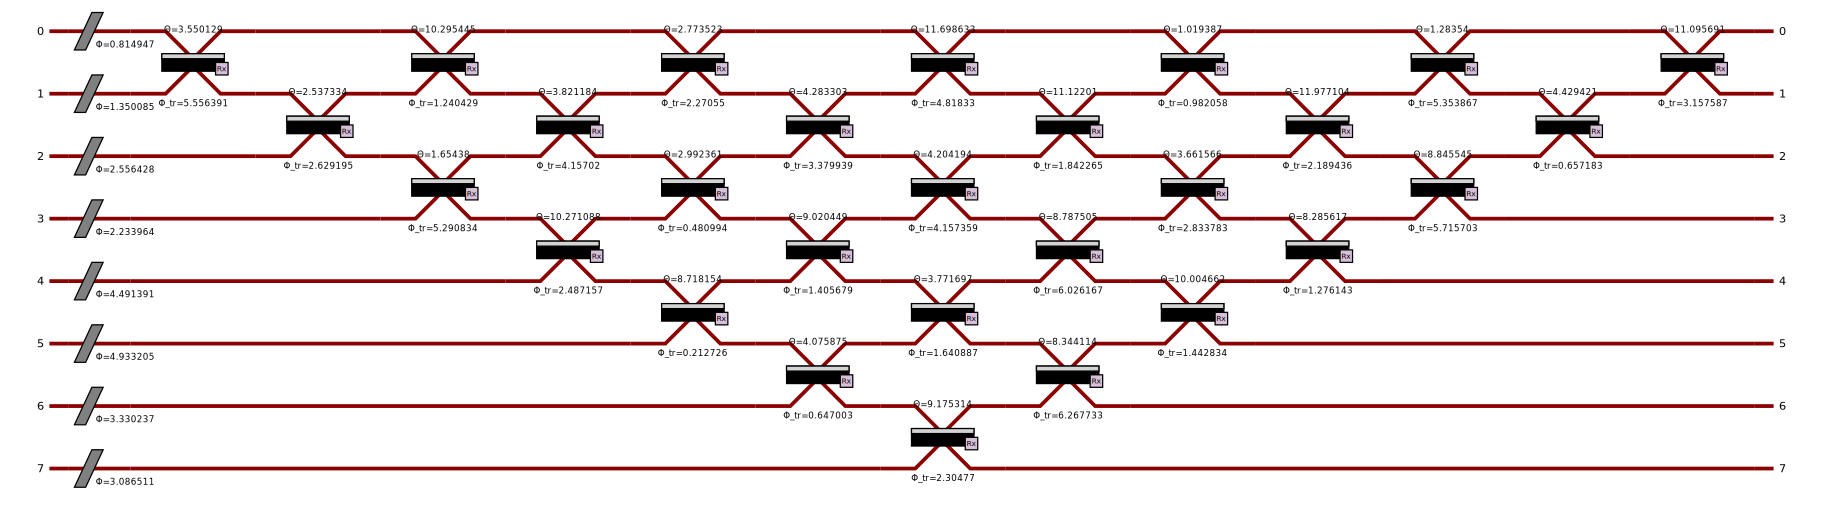

In [2]:
import perceval as pcvl
from perceval.components import BS, PS
import numpy as np

# 1. Recreate the exact 8x8 fixed Unitary from our Reservoir
MODES = 8
np.random.seed(42)
fixed_reservoir_matrix = pcvl.Matrix.random_unitary(MODES)

# 2. Decompose the giant Unitary into elementary optical "rotation" gates
print("Breaking down the Unitary into a physical hardware mesh...")
decomposed_circuit = pcvl.Circuit.decomposition(
    fixed_reservoir_matrix, 
    BS(theta=pcvl.P('theta'), phi_tr=pcvl.P('phi')), # The mixing gate
    phase_shifter_fn=PS                              # The phase rotation gate
)

print("Unitary successfully broken down!")

# 3. Print the massive decomposed gate circuit!
pcvl.pdisplay(decomposed_circuit)